In [4]:
# Install Detectron2 (run this only once)
# If using Google Colab, uncomment the below lines:
# !pip install -U torch torchvision
# !pip install 'git+https://github.com/facebookresearch/detectron2.git'

import os
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt

from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2.data.datasets import register_coco_instances
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader


In [5]:
DATASET_PATH = "/home/jazzy/sem-farm/datasets"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")
TEST_DIR = os.path.join(DATASET_PATH, "test")

ANNOT_PATHS = {
    "train": os.path.join(TRAIN_DIR, "_annotations.coco.json"),
    "valid": os.path.join(VALID_DIR, "_annotations.coco.json"),
    "test": os.path.join(TEST_DIR, "_annotations.coco.json"),
}


In [6]:
register_coco_instances("semfarm_train", {}, ANNOT_PATHS["train"], TRAIN_DIR)
register_coco_instances("semfarm_valid", {}, ANNOT_PATHS["valid"], VALID_DIR)
register_coco_instances("semfarm_test", {}, ANNOT_PATHS["test"], TEST_DIR)


In [9]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN = ("semfarm_train",)
cfg.DATASETS.TEST = ("semfarm_valid",)
cfg.DATALOADER.NUM_WORKERS = 4

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 0.0025
cfg.SOLVER.MAX_ITER = 3000
cfg.SOLVER.STEPS = (10000, 13000)
cfg.SOLVER.CHECKPOINT_PERIOD = 1000

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2  # Adjust based on your dataset

cfg.INPUT.MIN_SIZE_TRAIN = (640, 672, 704, 736, 768, 800)
cfg.INPUT.MAX_SIZE_TRAIN = 1333
cfg.INPUT.MIN_SIZE_TEST = 800
cfg.INPUT.MAX_SIZE_TEST = 1333
cfg.INPUT.RANDOM_FLIP = "horizontal"

cfg.OUTPUT_DIR = "./output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)


In [10]:
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()


[05/26 06:35:08 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (3, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (3,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (8, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (8,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (2, 256, 1, 1) in

[05/26 06:35:08 d2.engine.train_loop]: Starting training from iteration 0
[05/26 06:35:28 d2.utils.events]:  eta: 0:32:56  iter: 19  total_loss: 2.087  loss_cls: 0.9161  loss_box_reg: 0.3169  loss_mask: 0.6832  loss_rpn_cls: 0.1332  loss_rpn_loc: 0.03724    time: 0.9978  last_time: 0.5810  data_time: 0.0166  last_data_time: 0.0091   lr: 4.9952e-05  max_mem: 4932M
[05/26 06:35:49 d2.utils.events]:  eta: 0:32:42  iter: 39  total_loss: 1.538  loss_cls: 0.3966  loss_box_reg: 0.3927  loss_mask: 0.5921  loss_rpn_cls: 0.05957  loss_rpn_loc: 0.03055    time: 1.0334  last_time: 1.5246  data_time: 0.0130  last_data_time: 0.0158   lr: 9.9902e-05  max_mem: 4932M
[05/26 06:36:12 d2.utils.events]:  eta: 0:33:37  iter: 59  total_loss: 1.336  loss_cls: 0.3285  loss_box_reg: 0.4608  loss_mask: 0.464  loss_rpn_cls: 0.02541  loss_rpn_loc: 0.02998    time: 1.0653  last_time: 0.5413  data_time: 0.0140  last_data_time: 0.0069   lr: 0.00014985  max_mem: 5090M
[05/26 06:36:37 d2.utils.events]:  eta: 1:10:39  

[05/26 09:58:06 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


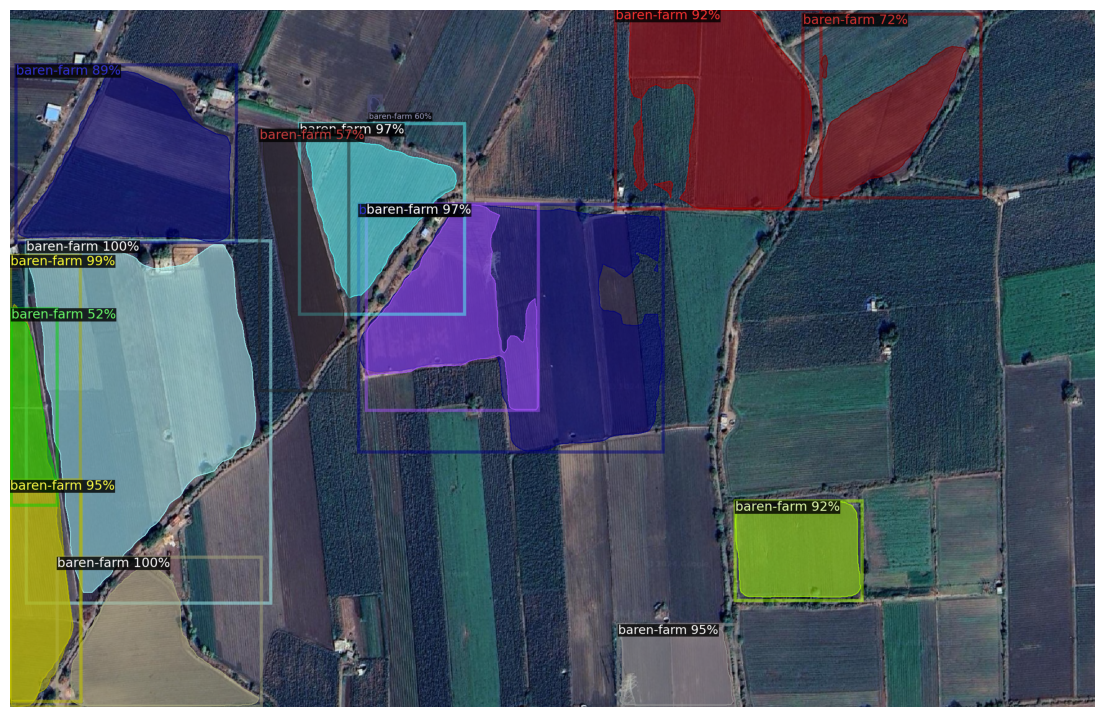

In [11]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
predictor = DefaultPredictor(cfg)

img_path = os.path.join(TEST_DIR, "/home/jazzy/sem-farm/data/final_farmland_jpg.jpg")  # Replace with your actual test image
im = cv2.imread(img_path)
outputs = predictor(im)

v = Visualizer(im[:, :, ::-1], MetadataCatalog.get("semfarm_train"), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(14, 10))
plt.imshow(out.get_image())
plt.axis('off')
plt.show()
